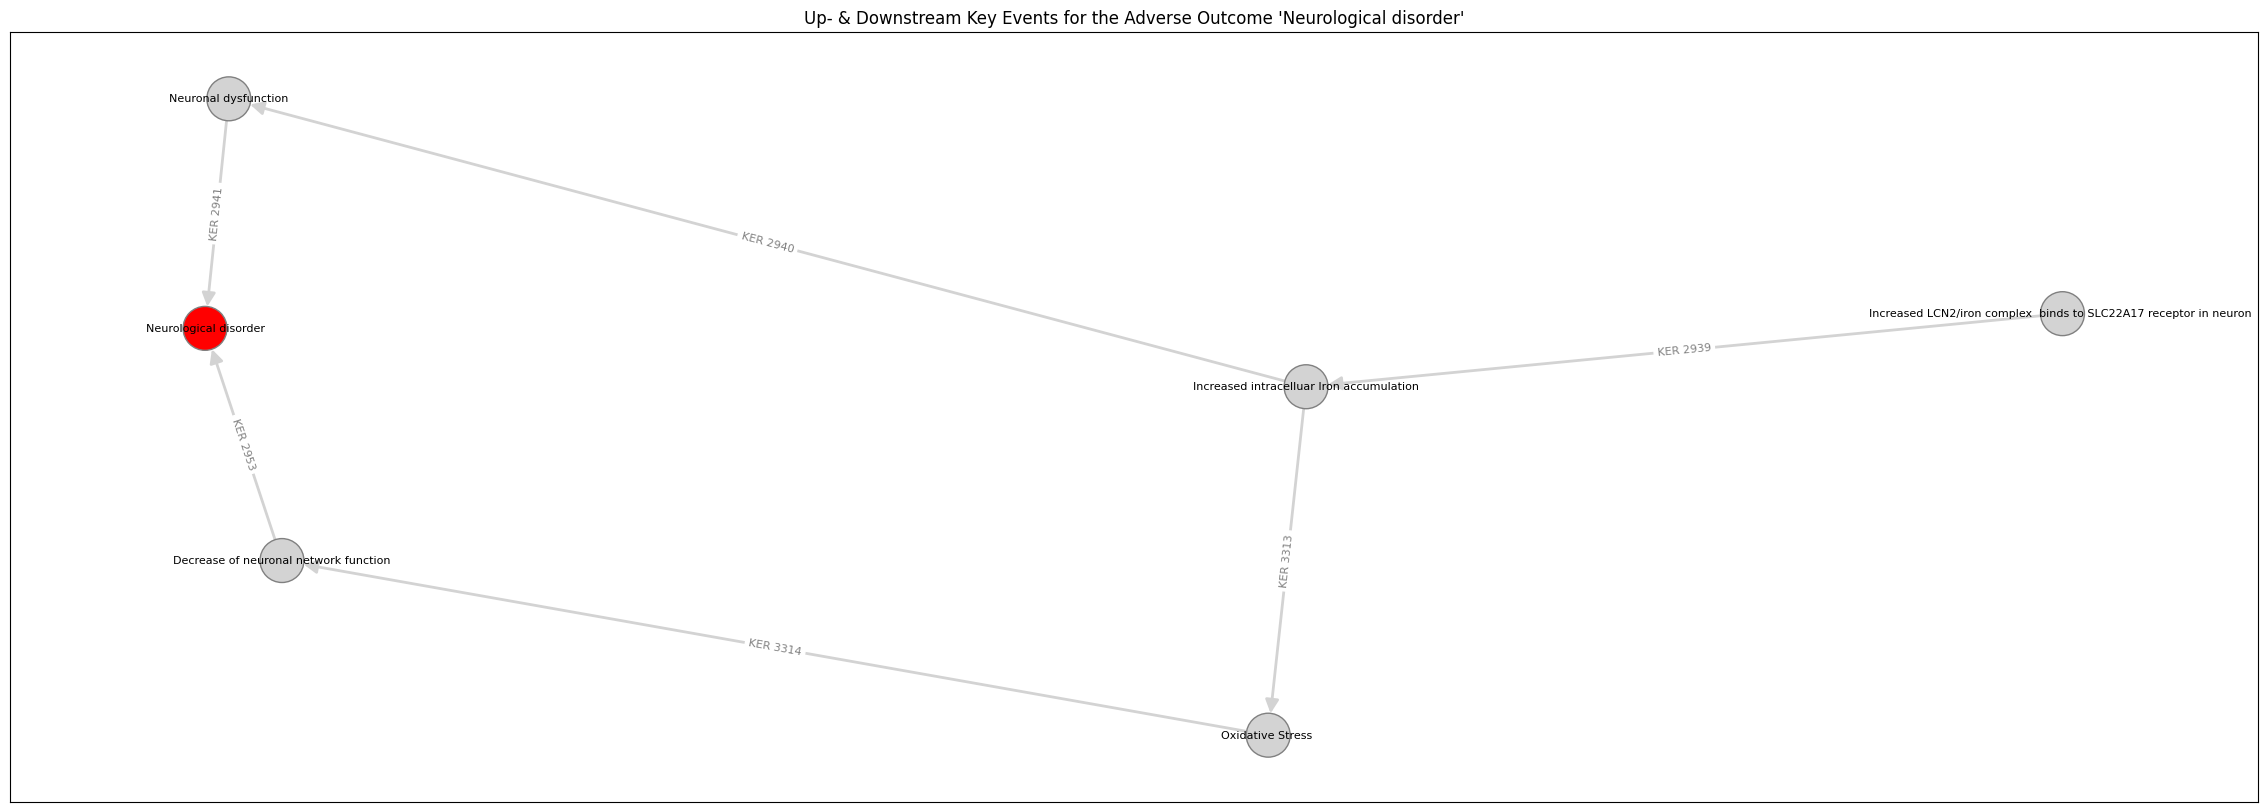

In [383]:
from SPARQLWrapper import SPARQLWrapper, JSON
import networkx as nx 
import matplotlib.pyplot as plt


SPARQL_ENDPOINT = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"
QUERY = """
SELECT DISTINCT ?AOP ?KER ?KERLabel ?Upstream ?UpstreamTitle ?Downstream ?DownstreamTitle
WHERE {
    ?AOP a aopo:AdverseOutcomePathway.
    ?AOP aopo:has_adverse_outcome ?AO.
    ?AO dc:identifier ?AOID.
    ?AO dc:title ?AOTitle.
    FILTER (?AOID = aop.events:2150)

    ?AO dcterms:isPartOf ?AOP.
    ?AOP aopo:has_key_event_relationship ?KER.
    ?KER aopo:has_upstream_key_event ?Upstream.
    ?KER aopo:has_downstream_key_event ?Downstream.

    ?Upstream dc:title ?UpstreamTitle.
    ?Downstream dc:title ?DownstreamTitle.
    ?KER rdfs:label ?KERLabel.
}
"""

# Initialize SPARQL wrapper and define result variables
sparql = SPARQLWrapper(SPARQL_ENDPOINT)
sparql.setQuery(QUERY)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()
bindings = results["results"]["bindings"]

# Initialise directed graph + node and edge list
G = nx.DiGraph()
node_labels = {}
edge_labels = {}

#Link nodes and edges to SPARQL results
for row in bindings:
    ker_label = row["KERLabel"]["value"]
    up_uri = row["Upstream"]["value"]
    up_title = row["UpstreamTitle"]["value"]
    down_uri = row["Downstream"]["value"]
    down_title = row["DownstreamTitle"]["value"]
    node_labels[up_uri] = up_title
    node_labels[down_uri] = down_title
    G.add_edge(up_uri, down_uri)
    edge_labels[(up_uri, down_uri)] = ker_label
#Prevent error and check for any results
if not G.edges:
    print("No upstream/downstream relationships.")

else:
    
    selected_AO = "https://identifiers.org/aop.events/2150"
    all_nodes = list(G.nodes())
    node_colors = []
    for node in all_nodes:
        if node == selected_AO:
            node_colors.append("red")        
        else:
            node_colors.append("lightgray")  
            
    #Network graph formatting
    plt.figure(figsize=(29, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color=node_colors, node_size=1000, edgecolors='gray')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='lightgray', width=2, node_size=1000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray', font_size=8)
    plt.title("Up- & Downstream Key Events for the Adverse Outcome 'Neurological disorder'")
    plt.show()


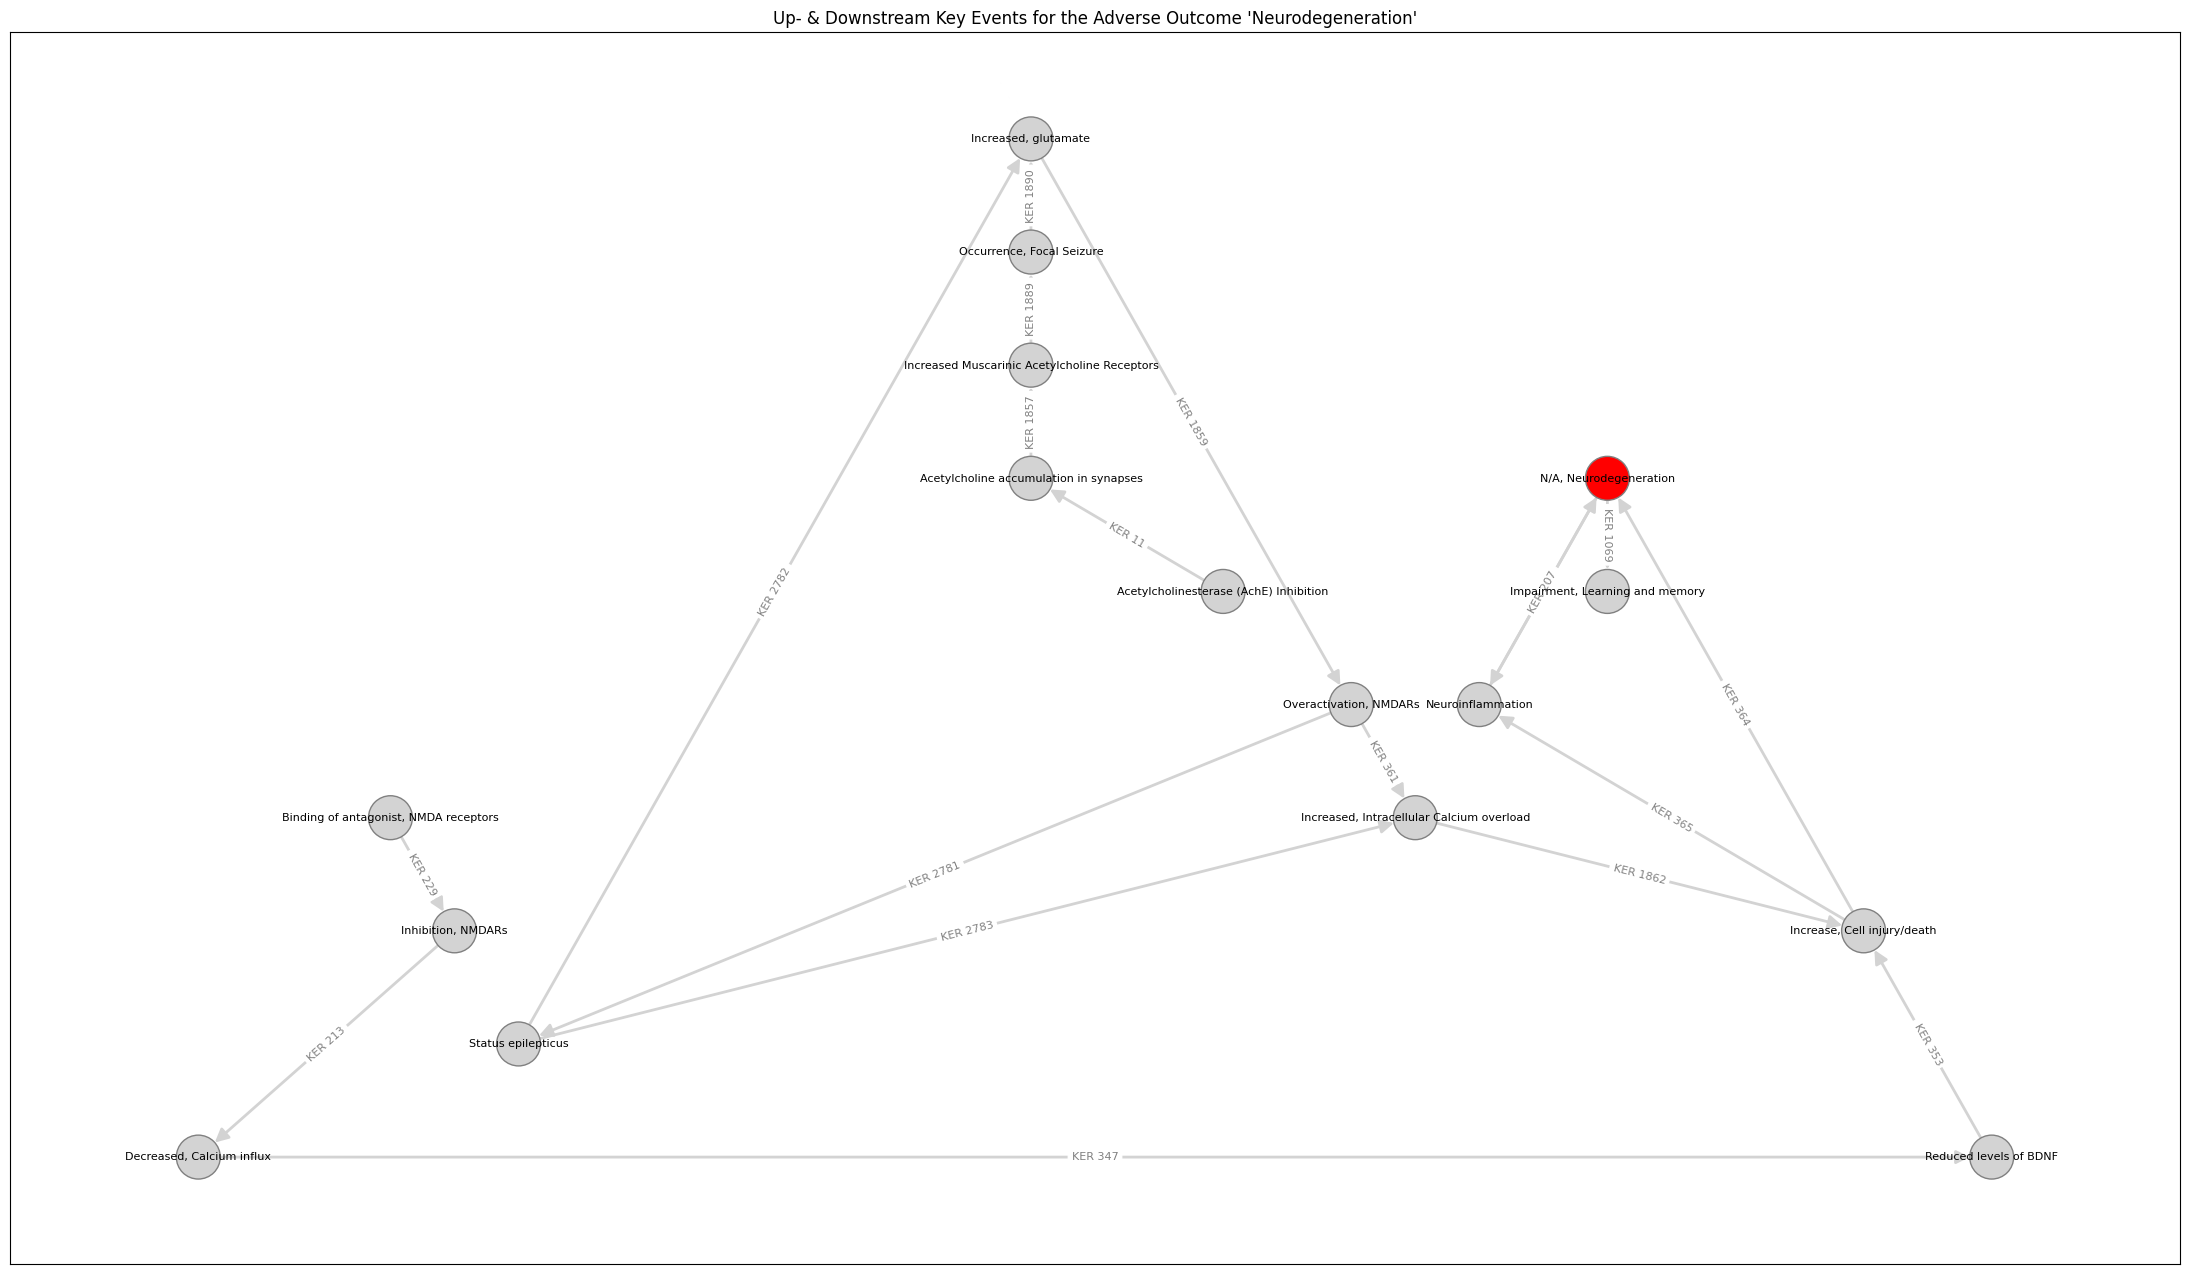

In [384]:
from SPARQLWrapper import SPARQLWrapper, JSON
import networkx as nx 
import matplotlib.pyplot as plt

SPARQL_ENDPOINT = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

QUERY = """

SELECT DISTINCT ?AOP ?KER ?KERLabel ?Upstream ?UpstreamTitle ?Downstream ?DownstreamTitle
WHERE {
    ?AOP a aopo:AdverseOutcomePathway.
    ?AOP aopo:has_adverse_outcome ?AO.
    ?AO dc:identifier ?AOID.
    ?AO dc:title ?AOTitle.
    FILTER (?AOID = aop.events:352)

    ?AO dcterms:isPartOf ?AOP.
    ?AOP aopo:has_key_event_relationship ?KER.
    ?KER aopo:has_upstream_key_event ?Upstream.
    ?KER aopo:has_downstream_key_event ?Downstream.

    ?Upstream dc:title ?UpstreamTitle.
    ?Downstream dc:title ?DownstreamTitle.
    ?KER rdfs:label ?KERLabel.
}
"""

# Initialize SPARQL wrapper
sparql = SPARQLWrapper(SPARQL_ENDPOINT)
sparql.setQuery(QUERY)
sparql.setReturnFormat(JSON)

results = sparql.query().convert()
bindings = results["results"]["bindings"]

# Initialise directed graph
G = nx.DiGraph()
# Initialise node and edge list
node_labels = {}
edge_labels = {}
#Link nodes and edges to SPARQL results
for row in bindings:
    ker_label = row["KERLabel"]["value"]
    up_uri = row["Upstream"]["value"]
    up_title = row["UpstreamTitle"]["value"]
    down_uri = row["Downstream"]["value"]
    down_title = row["DownstreamTitle"]["value"]
    node_labels[up_uri] = up_title
    node_labels[down_uri] = down_title
    G.add_edge(up_uri, down_uri)
    edge_labels[(up_uri, down_uri)] = ker_label

if not G.edges:
    print("No upstream/downstream relationships")
else:
    #Highlight Selected Key Event
    selected_AO = "https://identifiers.org/aop.events/352"
    all_nodes = list(G.nodes())
    node_colors = []
    for node in all_nodes:
        if node == selected_AO:
            node_colors.append("red")        
        else:
            node_colors.append("lightgray")  
            
    #Network formatting
    plt.figure(figsize=(28, 16))
    pos= nx.planar_layout(G)
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color=node_colors, node_size=1000, edgecolors='gray')
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='lightgray', width=2, node_size=1000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray', font_size=8)
    plt.title("Up- & Downstream Key Events for the Adverse Outcome 'Neurodegeneration'")
    plt.show()


In [388]:
def execute_sparql_query(endpoint, query):
    # Initialize SPARQLWrapper with the endpoint
    sparql = SPARQLWrapper(endpoint)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    
    # Execute the query and retrieve the results
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]
    
    # Return an empty DataFrame if there are no results
    if not bindings:
        return pd.DataFrame()
    
    # Extract column names from the first result entry
    columns = bindings[0].keys()
    
    # Convert results to a list of dictionaries
    data = []
    for row in bindings:
        data.append({col: row[col]['value'] for col in columns})
    
    # Convert list of dictionaries to a Pandas DataFrame
    return pd.DataFrame(data)

In [389]:
from SPARQLWrapper import SPARQLWrapper, JSON
import networkx as nx 
import matplotlib.pyplot as plt

SPARQL_ENDPOINT = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

QUERY = """

SELECT DISTINCT ?KERLabel ?KERID ?UpstreamTitle ?Upstream ?DownstreamTitle  ?Downstream
WHERE {
    ?AOP a aopo:AdverseOutcomePathway.
    ?AOP aopo:has_adverse_outcome ?AO.
    ?AO dc:identifier ?AOID.
    ?AO dc:title ?AOTitle.
    FILTER (?AOID = aop.events:2150)

    ?AO dcterms:isPartOf ?AOP.
    ?AOP aopo:has_key_event_relationship ?KERID.
    OPTIONAL{?KERID aopo:has_upstream_key_event ?Upstream.}
    OPTIONAL{?KERID aopo:has_downstream_key_event ?Downstream.}

    OPTIONAL{?Upstream dc:title ?UpstreamTitle.}
    OPTIONAL{?Downstream dc:title ?DownstreamTitle.}
    OPTIONAL{?KERID rdfs:label ?KERLabel.}
}
"""
df = execute_sparql_query(SPARQL_ENDPOINT, QUERY)
df.index = df.index + 1
df.rename(columns={"KERLabel": "Key Event Relationship Label", "KERID": "Key Event ID", "UpstreamTitle": "Upsteam Key Event", "Upstream": "Upstream Key Event ID", "DownstreamTitle": "Downstream Key Event", "Downstream": "Downstream Key Event ID"},inplace=True)
display(df)



,Key Event Relationship Label,Key Event ID,Upsteam Key Event,Upstream Key Event ID,Downstream Key Event,Downstream Key Event ID
1,KER 2939,https://identifiers.org/aop.relationships/2939,Increased LCN2/iron complex binds to SLC22A17 receptor in neuron,https://identifiers.org/aop.events/2148,Increased intracelluar Iron accumulation,https://identifiers.org/aop.events/2149
2,KER 2940,https://identifiers.org/aop.relationships/2940,Increased intracelluar Iron accumulation,https://identifiers.org/aop.events/2149,Neuronal dysfunction,https://identifiers.org/aop.events/191
3,KER 2941,https://identifiers.org/aop.relationships/2941,Neuronal dysfunction,https://identifiers.org/aop.events/191,Neurological disorder,https://identifiers.org/aop.events/2150
4,KER 2953,https://identifiers.org/aop.relationships/2953,Decrease of neuronal network function,https://identifiers.org/aop.events/386,Neurological disorder,https://identifiers.org/aop.events/2150
5,KER 3313,https://identifiers.org/aop.relationships/3313,Increased intracelluar Iron accumulation,https://identifiers.org/aop.events/2149,Oxidative Stress,https://identifiers.org/aop.events/1392
6,KER 3314,https://identifiers.org/aop.relationships/3314,Oxidative Stress,https://identifiers.org/aop.events/1392,Decrease of neuronal network function,https://identifiers.org/aop.events/386


In [390]:
from SPARQLWrapper import SPARQLWrapper, JSON
import networkx as nx 
import matplotlib.pyplot as plt

SPARQL_ENDPOINT = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

QUERY = """

SELECT DISTINCT ?KERLabel ?KERID ?UpstreamTitle ?Upstream ?DownstreamTitle  ?Downstream
WHERE {
    ?AOP a aopo:AdverseOutcomePathway.
    ?AOP aopo:has_adverse_outcome ?AO.
    ?AO dc:identifier ?AOID.
    ?AO dc:title ?AOTitle.
    FILTER (?AOID = aop.events:352)

    ?AO dcterms:isPartOf ?AOP.
    ?AOP aopo:has_key_event_relationship ?KERID.
    OPTIONAL{?KERID aopo:has_upstream_key_event ?Upstream.}
    OPTIONAL{?KERID aopo:has_downstream_key_event ?Downstream.}

    OPTIONAL{?Upstream dc:title ?UpstreamTitle.}
    OPTIONAL{?Downstream dc:title ?DownstreamTitle.}
    OPTIONAL{?KERID rdfs:label ?KERLabel.}
}
"""
df = execute_sparql_query(SPARQL_ENDPOINT, QUERY)
df.index = df.index + 1
df.rename(columns={"KERLabel": "Key Event Relationship Label", "KERID": "Key Event ID", "UpstreamTitle": "Upsteam Key Event", "Upstream": "Upstream Key Event ID", "DownstreamTitle": "Downstream Key Event", "Downstream": "Downstream Key Event ID"},inplace=True)
display(df)



,Key Event Relationship Label,Key Event ID,Upsteam Key Event,Upstream Key Event ID,Downstream Key Event,Downstream Key Event ID
1,KER 2781,https://identifiers.org/aop.relationships/2781,"Overactivation, NMDARs",https://identifiers.org/aop.events/388,Status epilepticus,https://identifiers.org/aop.events/1788
2,KER 213,https://identifiers.org/aop.relationships/213,"Inhibition, NMDARs",https://identifiers.org/aop.events/195,"Decreased, Calcium influx",https://identifiers.org/aop.events/52
3,KER 361,https://identifiers.org/aop.relationships/361,"Overactivation, NMDARs",https://identifiers.org/aop.events/388,"Increased, Intracellular Calcium overload",https://identifiers.org/aop.events/389
4,KER 207,https://identifiers.org/aop.relationships/207,"N/A, Neurodegeneration",https://identifiers.org/aop.events/352,Neuroinflammation,https://identifiers.org/aop.events/188
5,KER 1862,https://identifiers.org/aop.relationships/1862,"Increased, Intracellular Calcium overload",https://identifiers.org/aop.events/389,"Increase, Cell injury/death",https://identifiers.org/aop.events/55
6,KER 2783,https://identifiers.org/aop.relationships/2783,Status epilepticus,https://identifiers.org/aop.events/1788,"Increased, Intracellular Calcium overload",https://identifiers.org/aop.events/389
7,KER 365,https://identifiers.org/aop.relationships/365,"Increase, Cell injury/death",https://identifiers.org/aop.events/55,Neuroinflammation,https://identifiers.org/aop.events/188
8,KER 1857,https://identifiers.org/aop.relationships/1857,Acetylcholine accumulation in synapses,https://identifiers.org/aop.events/10,Increased Muscarinic Acetylcholine Receptors,https://identifiers.org/aop.events/1602
9,KER 1069,https://identifiers.org/aop.relationships/1069,"N/A, Neurodegeneration",https://identifiers.org/aop.events/352,"Impairment, Learning and memory",https://identifiers.org/aop.events/341
10,KER 229,https://identifiers.org/aop.relationships/229,"Binding of antagonist, NMDA receptors",https://identifiers.org/aop.events/201,"Inhibition, NMDARs",https://identifiers.org/aop.events/195
